In [1]:
import sys
from pathlib import Path 

project_root = Path().resolve().parent

sys.path.append(str(project_root))

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 


from App_files.dataframe_loader import df_loader
from App_files.Pipeline import log_model_with_mlflow
from App_files.model_factory import select_model
from App_files.preprocessing_pipeline import preprocessing_pipeline 
from config.config import logger 
from App_files.data_loader import target_feature , data_split

from visualizations.model_plots import plot_model_comparison

In [3]:
logger.info("Loading dataframe for manual testing of the 3NF dataframe with Machine Learning algorithms")
df = df_loader()
logger.info("Dataframe loaded successfully!")

2025-07-15 18:56:19 | INFO | root | Loading dataframe for manual testing of the 3NF dataframe with Machine Learning algorithms
2025-07-15 18:56:19 | INFO | root | Creating Connection to the database
2025-07-15 18:56:19 | INFO | root | Connection created successfully
2025-07-15 18:56:19 | INFO | root | Creating tables
2025-07-15 18:56:19 | INFO | root | Tables created successfully
2025-07-15 18:56:19 | INFO | root | Loading the database and Normalizing for a 3NF..
2025-07-15 18:56:19 | INFO | root | Normalization done !.
2025-07-15 18:56:19 | INFO | root | Inserting data to the tables


Removed exisiting database /Users/ajit/Desktop/loan_predictor_app/data/LoanDATABASE.db
Connected to database: /Users/ajit/Desktop/loan_predictor_app/data/LoanDATABASE.db
Table created successfully.
Table created successfully.
Table created successfully.
Table created successfully.
Table created successfully.
Data inserted successfully.
Data inserted successfully.
Data inserted successfully.
Data inserted successfully.


2025-07-15 18:56:19 | INFO | root | All data inserted successfully
2025-07-15 18:56:19 | INFO | root | 🧹 Tables created, data inserted, and DB connection closed.
2025-07-15 18:56:19 | INFO | root | Dataframe loaded successfully!


Data inserted successfully.


In [4]:
X,y = target_feature(df=df)

In [5]:
X_train,X_test,y_train,y_test = data_split(X,y)

In [6]:
model1 = select_model("logistic")
model2 = select_model("ridge", alpha=1.0)
model3 = select_model("random_forest", n_estimators=100)
model4 = select_model("xgboost", learning_rate=0.1)


In [7]:
logger.info("split the data into target and features and defined models")

2025-07-15 18:56:19 | INFO | root | split the data into target and features and defined models


In [8]:
preprocessor,Numeric_features,Categorical_features  = preprocessing_pipeline(df)


In [9]:
models = { 
    "Logistic Regression " : model1,
    "Ridge Classifier" : model2,
    "RandomForestClassifier" : model3,
    "XGBClassifier" : model4
}

In [10]:
results = {}

for name,model in models.items():

    acc,f1  = log_model_with_mlflow(name=name,model=model,preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test)

    results[name] = {
        "accuracy": acc,
        "f1_score": f1
    }


2025-07-15 18:56:25 | INFO | root | ✅ Logistic Regression  → Accuracy: 1.0000, F1 Score: 1.0000


🏃 View run Logistic Regression  at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4/runs/bc7ba243a3e4430f99383447f042a49b
🧪 View experiment at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4


2025-07-15 18:57:13 | INFO | root | ✅ Ridge Classifier → Accuracy: 0.9995, F1 Score: 0.9995


🏃 View run Ridge Classifier at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4/runs/53a582c9bad7419092badc67a62f0e6f
🧪 View experiment at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4


2025-07-15 18:58:19 | INFO | root | ✅ RandomForestClassifier → Accuracy: 0.9718, F1 Score: 0.9712


🏃 View run RandomForestClassifier at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4/runs/c3292a6dc66a49ff9d8d53d4f74bf22c
🧪 View experiment at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4


/Users/ajit/Desktop/loan_predictor_app/Loan_App/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:58:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025-07-15 18:58:36 | INFO | root | ✅ XGBClassifier → Accuracy: 0.9978, F1 Score: 0.9977


🏃 View run XGBClassifier at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4/runs/25e560e9d49c4a4989b96f3e1c76c966
🧪 View experiment at: https://dagshub.com/ajitkumarsenthil5/Loan_Approval_logs.mlflow/#/experiments/4


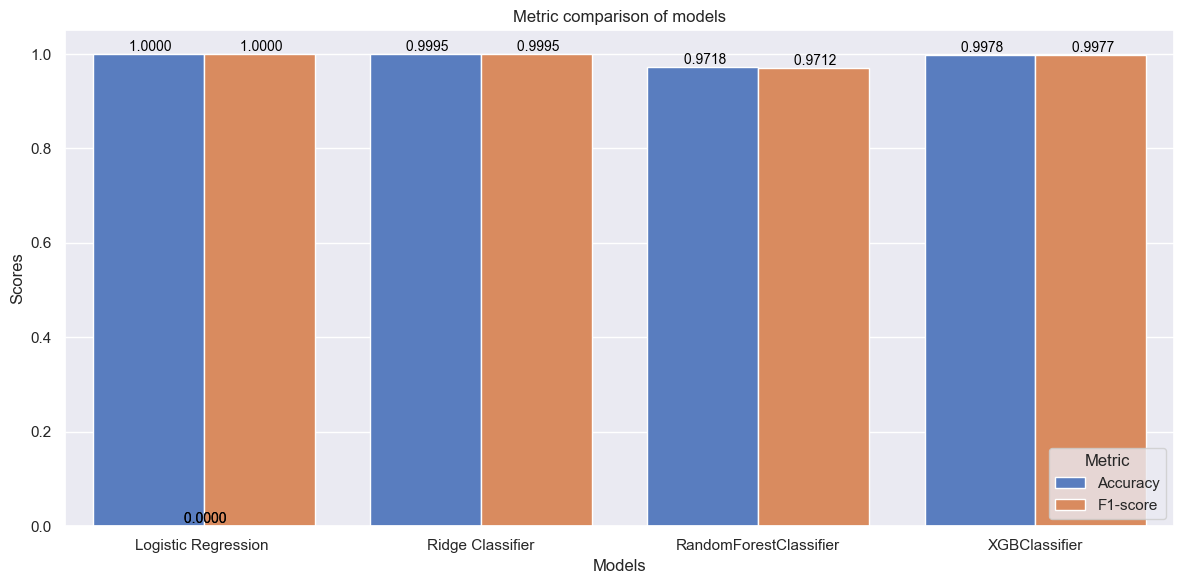

In [11]:
plot_model_comparison(results=results)